## Check agains the BH code

The first requirement we want to satisfy is that the NS version of precession return the same result as precession when k1=k2=1 (i.e., in the BH case). We are going to check this for the most used functions in the code: 
- (1) measure the precession timescale,
- (2) perfrom a precession average of a generic function
- (3) evolve of a binary system. 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

import precession_NS as pre_ns #my version of precession with NS spin precession eqautions
import precession as pre # classic precession 

### Initial conidtions

Here we define the parameters of a binary system for which we want to measure the precessional timescale ( a fixed separation r) 

In [2]:
#this function randomly selects the spin angles considering an isotropic distribution
theta1, theta2, deltaphi=pre.isotropic_angles(N=1)

r0=100.
q=0.8
chi1=0.1
chi2=0.8

deltachi=pre.eval_deltachi(theta1, theta2, q, chi1, chi2 )
kappa = pre.eval_kappa(theta1=theta1,theta2=theta2,deltaphi=deltaphi,r=r0,q=q,chi1=chi1,chi2=chi2)
#BH case!
k1=1.
k2=1.
#they must coincide!
chicons= pre_ns.eval_chicons(theta1, theta2, r0, q, chi1, chi2, k1, k2 )
chieff=pre.eval_chieff(theta1, theta2, q, chi1, chi2)

print(chieff, chicons,(chieff-chicons)/chicons )

#this is super slow compared to Davide  precession :(

[-0.1104098] [-0.1104098] [-7.29021952e-15]


## (1) measure the precession timescale
To compute the precession timescale we need to integrate $dt/ \delta \chi$ between $\delta \chi_{-}$ and $\delta \chi_{+}$. The first step is to find $\delta \chi_{-}$ and $\delta \chi_{+}$ which are zeros of the $(d \delta \chi/dt)^2$. Let's check if the two codes find the roots.

In [3]:
u=pre.eval_u(r0, q)
#Davide's precession 
deltachiminus,deltachiplus,deltachi3 = pre.deltachiroots(kappa, u, chieff, q, chi1, chi2)
NS_roots = pre_ns.deltachi_plusminus(kappa, u, chicons, q, chi1, chi2, k1, k2)
print('Davide precession :', deltachiminus[0],deltachiplus[0])
print('NS precession :',NS_roots[0],NS_roots[1])
print(np.abs(deltachiminus-NS_roots[0])/np.abs(NS_roots[0]),np.abs(deltachiplus-NS_roots[1])/np.abs(NS_roots[1]))

Davide precession : 0.1988546126501777 0.2214588652004273
NS precession : 0.19885461265025625 0.22145886520042335
[3.95003555e-13] [1.77969472e-14]


In [4]:
# precessional period
tauNS=pre_ns.eval_tau(kappa, r0, chicons,  q, chi1, chi2, k1, k2)
tauBH=pre.eval_tau(kappa, r0, chieff,  q, chi1, chi2)
print("tau Davide =", (tauBH)[0])
print("tau NS =",(tauNS)[0])
print("relative error",(np.abs( tauNS-tauBH))/(np.abs( tauNS)))

tau Davide = 3948159.3986083916
tau NS = 3948159.396142058
relative error [6.2467933e-10]


## (2) precession average a generic function

In [4]:
def generic_func(x):
    return x**2+4*np.sin(x)



func_aveBH = pre.precession_average(kappa=kappa, r=r0, chieff=chieff, q=q, chi1=chi1, chi2=chi2, func=generic_func)
func_aveNS = pre_ns.precession_average(kappa=kappa, r=r0, chicons=chicons, q=q, chi1=chi1, chi2=chi2,k1=k1,k2=k2,func=generic_func)
print(func_aveNS,func_aveBH, np.abs(func_aveNS-func_aveBH)/np.abs(func_aveNS))

[0.87882812] [0.87882812] [2.95108252e-10]


## (3) evolution of a binary system. 

Here we will evolve our bianry system from r=100M to r=10 M. We care about the spin so we want to check the evoltuion of $\delta \chi_{-}$ and $\delta \chi_{+}$ as a function of r (evelope wihtin whcih precession happen), the evolution of $\chi_{\rm cons}$ and $\chi_{\rm eff}$ and $\kappa$. In the BH case we expect no evolution of $\chi_{\rm eff}$ so we shoudl recover that with our code. 

In [5]:
r=np.logspace(2,1,1000)
outputs = pre.inspiral_precav(theta1=theta1,theta2=theta2,deltaphi=deltaphi,r=r,q=q,chi1=chi1,chi2=chi2)
print(outputs)

{'theta1': array([[0.26028362, 0.63380078, 0.46387726, 0.41052622, 0.19856652,
        0.43726816, 0.43546995, 0.15174573, 0.33570004, 0.19061565,
        0.19546008, 0.27245608, 0.5733685 , 0.45709437, 0.6428012 ,
        0.0403534 , 0.63820338, 0.59816277, 0.5828051 , 0.64489518,
        0.38078673, 0.32149678, 0.12379582, 0.50041984, 0.28076379,
        0.1792627 , 0.04856527, 0.19612807, 0.62673251, 0.44276207,
        0.58853291, 0.33999131, 0.63916993, 0.05007566, 0.66573737,
        0.59590441, 0.66585361, 0.19955154, 0.38650944, 0.66833058,
        0.66881474, 0.58101166, 0.50473865, 0.61667489, 0.66996181,
        0.64691715, 0.29776637, 0.66020916, 0.51320459, 0.6611287 ,
        0.61940636, 0.65646523, 0.32071386, 0.66015577, 0.44500639,
        0.35454679, 0.40223869, 0.6460933 , 0.09067781, 0.67806358,
        0.4012372 , 0.65864525, 0.29339077, 0.10856379, 0.26073715,
        0.57529697, 0.3343914 , 0.12887204, 0.34899094, 0.64143378,
        0.61057888, 0.27072971, 0.241

In [18]:
outputsNS = pre_ns.inspiral_precav(theta1=theta1,theta2=theta2,deltaphi=deltaphi,r=r,q=q,chi1=chi1,chi2=chi2, k1=k1,k2=k2)
#this is super slow compared to Davide  precession :(

Text(0.5, 0, '$r$')

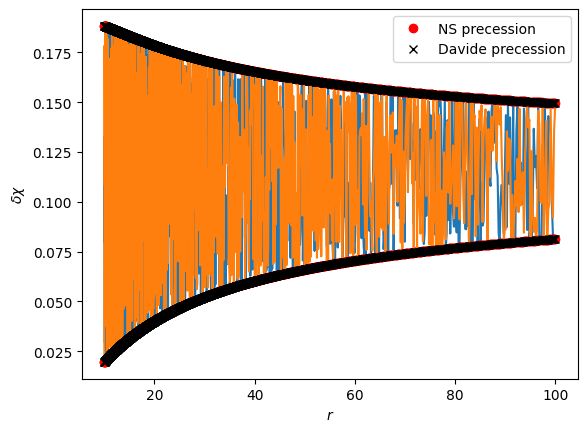

In [19]:
plt.plot(r,outputsNS['deltachi'].T) 
plt.plot(r,outputsNS['deltachiplus'].T, 'ro', label='NS precession')
plt.plot(r,outputsNS['deltachiminus'].T, 'ro')

plt.plot(r,outputs['deltachi'].T)
plt.plot(r,outputs['deltachiplus'].T, 'kx', label='Davide precession')
plt.plot(r,outputs['deltachiminus'].T, 'kx')
plt.legend()
plt.ylabel(r'$\delta \chi$')
plt.xlabel(r'$r$')

The orange and blue curves are not expected to coincide, since they are samples of $\delta \chi$. This means that if I re-run this code (using just Davide's precession), I will find a different realization/draw of $\delta \chi$ samples. The most important point is that the boundaries ($\delta \chi_+$ and $\delta \chi_-$, corresponding to the upper and lower points/crosses) obtained with the two codes coincide.

Text(0, 0.5, '$\\chi_{\\rm eff}\\, (\\chi_{\\rm cons})$')

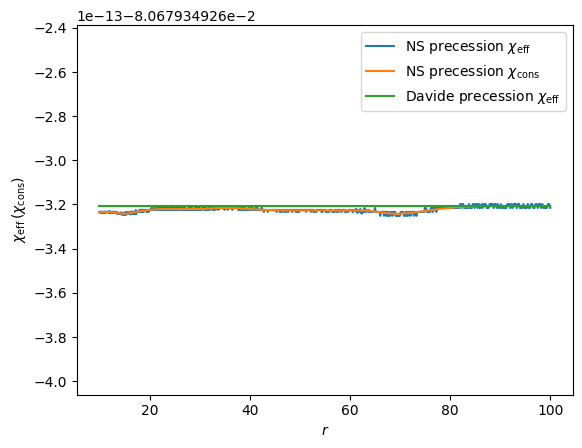

In [20]:
plt.plot(r,outputsNS['chieff'].T, label=r'NS precession $\chi_{\rm eff}$')
plt.plot(r,outputsNS['chicons'].T, label=r'NS precession $\chi_{\rm cons}$')
plt.plot(r,np.ones_like(r)*outputs['chieff'].T, label=r'Davide precession $\chi_{\rm eff}$')
plt.legend()
plt.xlabel(r'$r$')
plt.ylabel(r'$\chi_{\rm eff}\, (\chi_{\rm cons})$')


Text(0, 0.5, 'relative difference $\\chi_{\\rm eff} - \\chi_{\\rm cons}$ [NS precession]')

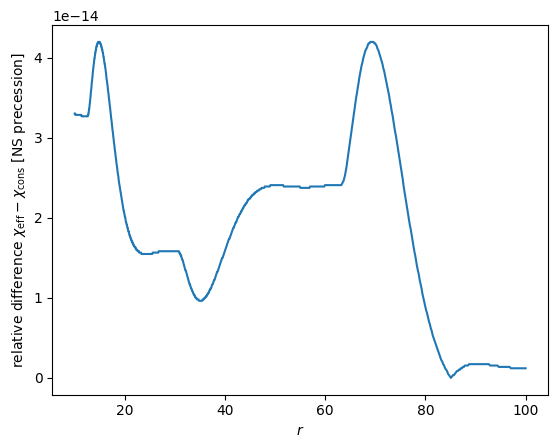

In [21]:

chieffcom=(np.abs(outputs['chieff']-outputsNS['chicons'])/np.abs(outputsNS['chicons']))[0]
plt.plot(r,chieffcom)
plt.xlabel(r'$r$')
plt.ylabel(r'relative difference $\chi_{\rm eff} - \chi_{\rm cons}$ [NS precession]')


## Orbit averaged evolution

In [6]:
r=np.logspace(2,1,1000)
outputsorb = pre.inspiral_orbav(theta1=theta1,theta2=theta2,deltaphi=deltaphi,r=r,q=q,chi1=chi1,chi2=chi2)
print(outputs)

{'theta1': array([[0.26028362, 0.63380078, 0.46387726, 0.41052622, 0.19856652,
        0.43726816, 0.43546995, 0.15174573, 0.33570004, 0.19061565,
        0.19546008, 0.27245608, 0.5733685 , 0.45709437, 0.6428012 ,
        0.0403534 , 0.63820338, 0.59816277, 0.5828051 , 0.64489518,
        0.38078673, 0.32149678, 0.12379582, 0.50041984, 0.28076379,
        0.1792627 , 0.04856527, 0.19612807, 0.62673251, 0.44276207,
        0.58853291, 0.33999131, 0.63916993, 0.05007566, 0.66573737,
        0.59590441, 0.66585361, 0.19955154, 0.38650944, 0.66833058,
        0.66881474, 0.58101166, 0.50473865, 0.61667489, 0.66996181,
        0.64691715, 0.29776637, 0.66020916, 0.51320459, 0.6611287 ,
        0.61940636, 0.65646523, 0.32071386, 0.66015577, 0.44500639,
        0.35454679, 0.40223869, 0.6460933 , 0.09067781, 0.67806358,
        0.4012372 , 0.65864525, 0.29339077, 0.10856379, 0.26073715,
        0.57529697, 0.3343914 , 0.12887204, 0.34899094, 0.64143378,
        0.61057888, 0.27072971, 0.241

In [7]:
outputsNSorb = pre_ns.inspiral_orbav(theta1=theta1,theta2=theta2,deltaphi=deltaphi,r=r,q=q,chi1=chi1,chi2=chi2, k1=k1,k2=k2)

#this is super slow compared to Davide  precession :(

True True True


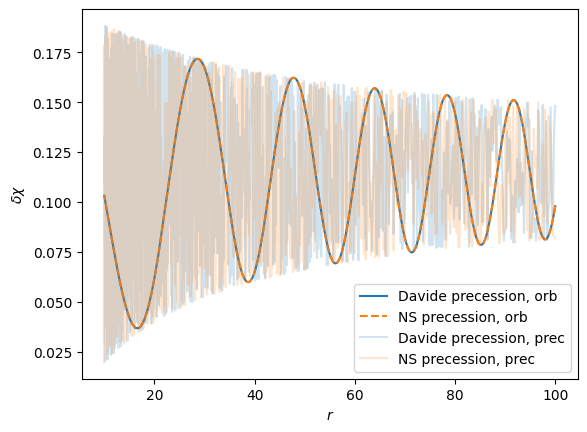

In [26]:
plt.plot(outputsorb['r'][0],outputsorb['deltachi'][0], label='Davide precession, orb')
plt.plot(outputsNSorb['r'][0],outputsNSorb['deltachi'][0], ls='--',label='NS precession, orb')
plt.plot(outputs['r'][0],outputs['deltachi'][0],color='tab:blue', alpha=0.2, label='Davide precession, prec')
plt.plot(outputsNS['r'][0],outputsNS['deltachi'][0],color='tab:orange',alpha=0.2,  label='NS precession, prec')
plt.ylabel(r'$\delta \chi$')
plt.xlabel('$r$')
plt.legend()

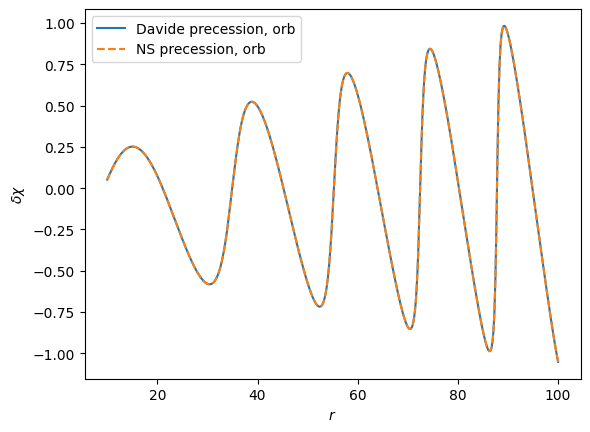

In [8]:
plt.plot(outputsorb['r'][0],outputsorb['deltaphi'][0], label='Davide precession, orb')
plt.plot(outputsNSorb['r'][0],outputsNSorb['deltaphi'][0], ls='--',label='NS precession, orb')

plt.ylabel(r'$\delta \chi$')
plt.xlabel('$r$')
plt.legend()

the goal would be to have the same plot but for an evolution where a bifocation appear